1. Montar Google Drive

In [75]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


2. Definir ruta del dataset

In [76]:
import os

BASE = "/content/drive/MyDrive/DAIC-WOZ"

print("Existe:", os.path.exists(BASE))
print("Número de archivos:", len(os.listdir(BASE)))

Existe: True
Número de archivos: 1716


3. Librerías

In [77]:
import os
import numpy as np
import pandas as pd

import librosa
import librosa.display

import matplotlib.pyplot as plt

import torch
import torch.nn as nn

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

4. Cargar audio a 16 kHz

In [78]:
AUDIO_FILE = f"{BASE}/300_AUDIO.wav"

y, sr = librosa.load(
    AUDIO_FILE,
    sr=16000,
    mono=True
)

print("Frecuencia:", sr)
print("Muestras:", len(y))

duracion = librosa.get_duration(y=y, sr=sr)

print(f"Duración: {duracion:.2f} segundos")

Frecuencia: 16000
Muestras: 10376000
Duración: 648.50 segundos


5. Forma de onda

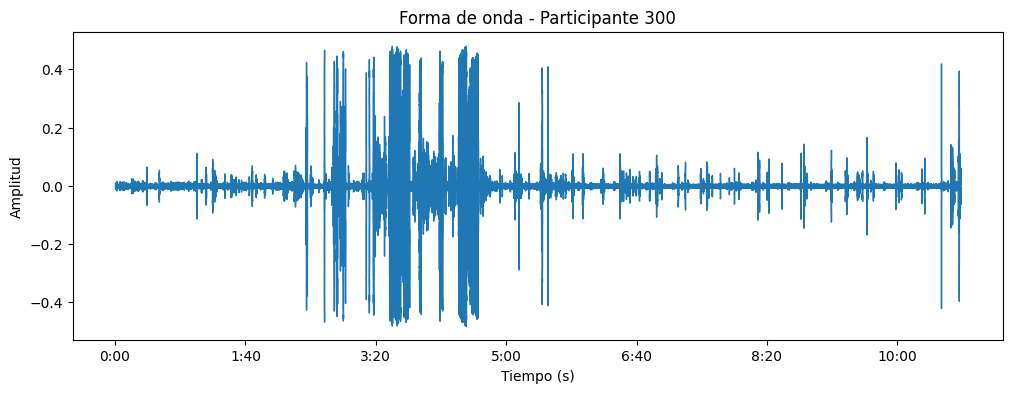

In [79]:
plt.figure(figsize=(12,4))

librosa.display.waveshow(
    y,
    sr=sr
)

plt.title("Forma de onda - Participante 300")
plt.xlabel("Tiempo (s)")
plt.ylabel("Amplitud")

plt.show()

6. Espectrograma

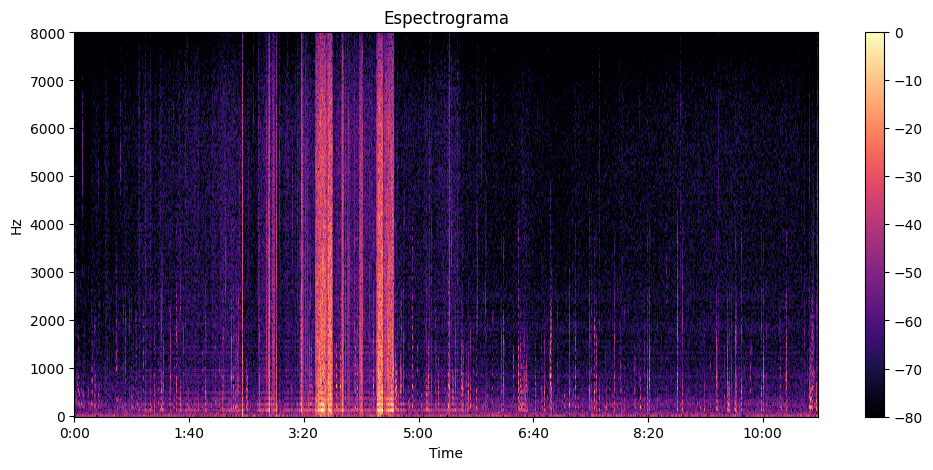

In [63]:
D = librosa.amplitude_to_db(
    np.abs(
        librosa.stft(
            y,
            n_fft=512,
            hop_length=256
        )
    ),
    ref=np.max
)

plt.figure(figsize=(12,5))

librosa.display.specshow(
    D,
    sr=sr,
    hop_length=256,
    x_axis='time',
    y_axis='hz'
)

plt.colorbar()
plt.title("Espectrograma")
plt.show()

7. MFCC

In [80]:
mfcc = librosa.feature.mfcc(
    y=y,
    sr=sr,
    n_mfcc=13,
    n_fft=512,
    hop_length=256
)

print(mfcc.shape)

(13, 40532)


8. Heatmap MFCC

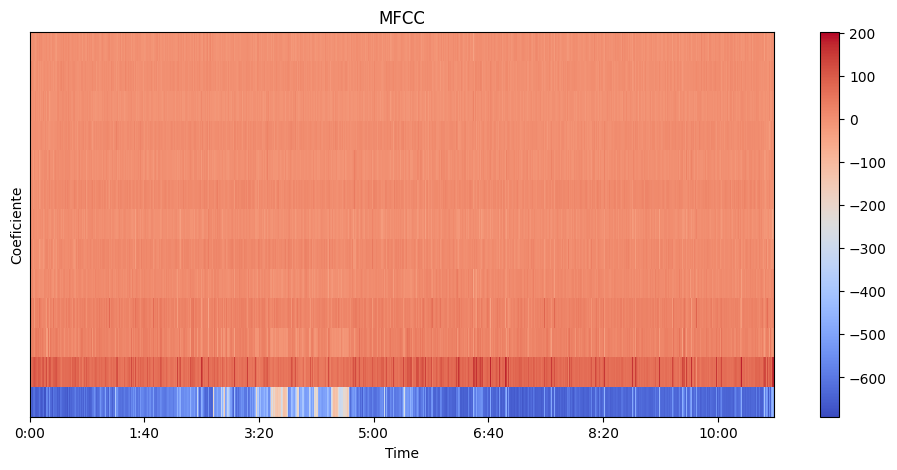

In [81]:
plt.figure(figsize=(12,5))

librosa.display.specshow(
    mfcc,
    sr=sr,
    hop_length=256,
    x_axis='time'
)

plt.colorbar()
plt.title("MFCC")
plt.ylabel("Coeficiente")

plt.show()

9. Delta y Delta-Delta

In [82]:
delta = librosa.feature.delta(mfcc)

delta2 = librosa.feature.delta(
    mfcc,
    order=2
)

print(delta.shape)
print(delta2.shape)

(13, 40532)
(13, 40532)


10. ZCR

In [83]:
zcr = librosa.feature.zero_crossing_rate(
    y,
    frame_length=512,
    hop_length=256
)

print(zcr.shape)

(1, 40532)


11. RMS

In [84]:
rms = librosa.feature.rms(
    y=y,
    frame_length=512,
    hop_length=256
)

print(rms.shape)

(1, 40532)


12. Graficar ZCR y RMS

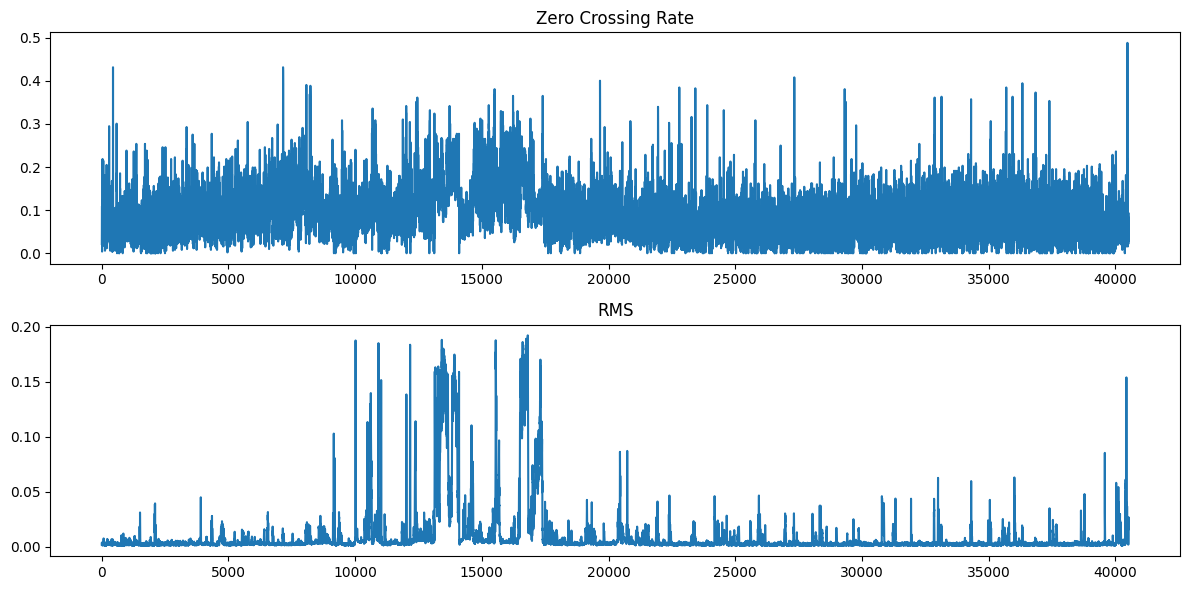

In [85]:
fig, ax = plt.subplots(
    2,
    1,
    figsize=(12,6)
)

ax[0].plot(zcr[0])
ax[0].set_title("Zero Crossing Rate")

ax[1].plot(rms[0])
ax[1].set_title("RMS")

plt.tight_layout()
plt.show()

13. Función principal

In [70]:
def extract_features(wav_path):

    y, sr = librosa.load(
        wav_path,
        sr=16000
    )

    y, _ = librosa.effects.trim(
        y,
        top_db=20
    )

    mfcc = librosa.feature.mfcc(
        y=y,
        sr=sr,
        n_mfcc=13,
        n_fft=512,
        hop_length=256
    )

    delta = librosa.feature.delta(mfcc)

    zcr = librosa.feature.zero_crossing_rate(
        y,
        frame_length=512,
        hop_length=256
    )

    rms = librosa.feature.rms(
        y=y,
        frame_length=512,
        hop_length=256
    )

    features = np.concatenate([
        mfcc.mean(axis=1),
        mfcc.std(axis=1),

        delta.mean(axis=1),
        delta.std(axis=1),

        zcr.mean(axis=1),
        zcr.std(axis=1),

        rms.mean(axis=1),
        rms.std(axis=1)
    ])

    return features

14. Prueba con el participante 300

In [86]:
features = extract_features(
    f"{BASE}/300_AUDIO.wav"
)

print(features.shape)
print(features)

(56,)
[-5.62837402e+02  7.34872589e+01  1.95371418e+01  2.34645042e+01
  8.02814007e+00  1.00790567e+01  2.78755456e-01  1.07302885e+01
  6.00087166e-01  4.30319023e+00 -3.45120430e+00  8.92509282e-01
 -2.31272531e+00  1.17912102e+02  2.63999062e+01  1.65130310e+01
  1.24591684e+01  9.58596706e+00  1.00330229e+01  9.78549767e+00
  8.28607559e+00  8.03327179e+00  7.34387779e+00  6.68265724e+00
  6.62397194e+00  6.83968401e+00 -2.10566283e-03  8.50777200e-04
  1.09335978e-03 -4.87073325e-04  6.34162629e-04  7.12509849e-04
  6.63332976e-05 -7.47621641e-04 -6.15418889e-04  1.67691818e-04
  1.13053444e-04 -7.19180607e-05 -3.46728833e-04  5.31610918e+00
  2.91646767e+00  2.33462620e+00  1.84975684e+00  1.27466965e+00
  1.35375571e+00  1.29567242e+00  1.11631918e+00  1.13481557e+00
  1.04327846e+00  9.36447322e-01  9.70320225e-01  9.54429924e-01
  9.26405565e-02  5.45408531e-02  1.01267574e-02  2.52685715e-02]


15.Procesar varios participantes

In [87]:
import pandas as pd

df = pd.read_csv(
    f"{BASE}/dev_split_Depression_AVEC2017.csv"
)

df.head()

,Participant_ID,PHQ8_Binary,PHQ8_Score,Gender,PHQ8_NoInterest,PHQ8_Depressed,PHQ8_Sleep,PHQ8_Tired,PHQ8_Appetite,PHQ8_Failure,PHQ8_Concentrating,PHQ8_Moving
0,302,0,4,1,1,1,0,1,0,1,0,0
1,307,0,4,0,0,1,0,1,0,2,0,0
2,331,0,8,1,1,1,1,1,1,1,1,1
3,335,1,12,0,1,1,3,2,3,1,1,0
4,346,1,23,0,2,3,3,3,3,3,3,3


16. Procesando cinco participantes

In [88]:
resultados = []

for pid in df["Participant_ID"][:5]:

    archivo = f"{BASE}/{pid}_AUDIO.wav"

    if os.path.exists(archivo):

        feats = extract_features(archivo)

        resultados.append(
            [pid] + feats.tolist()
        )

audio_df = pd.DataFrame(resultados)

print(audio_df.shape)
audio_df.head()


(5, 57)


,0,1,2,3,4,5,6,7,8,9,...,47,48,49,50,51,52,53,54,55,56
0,302,-628.065491,85.837204,18.130131,28.839962,10.693590,7.949943,3.445552,11.258050,0.273345,...,1.284878,1.149795,1.192201,1.084821,1.056796,1.026468,0.062835,0.046818,0.003345,0.003512
1,307,-399.409943,135.512924,10.292512,16.036720,-0.170383,-9.220669,-6.002573,-1.148630,1.135576,...,1.782385,1.727312,1.462883,1.400342,1.446967,1.264807,0.065932,0.034181,0.062120,0.061913
2,331,-676.631287,84.272331,8.001562,16.643438,9.928638,9.669562,-1.816520,2.916625,2.823438,...,1.925988,1.636773,1.870320,1.570198,1.462082,1.578309,0.077098,0.084146,0.004830,0.007765
3,335,-690.183105,69.315552,10.191752,17.042059,3.813462,0.894242,2.987743,3.775255,3.621278,...,2.041277,1.819966,1.600702,1.601002,1.356951,1.223468,0.082290,0.094064,0.003645,0.005358
4,346,-705.637390,78.703415,17.646391,17.505991,5.386515,2.876017,-0.072155,2.653126,5.542233,...,1.942961,2.167842,1.635025,1.810720,1.456689,1.460405,0.076786,0.080702,0.002978,0.004159


17. procesar todos los participantes

In [89]:
resultados = []

for pid in df["Participant_ID"]:

    archivo = f"{BASE}/{pid}_AUDIO.wav"

    if os.path.exists(archivo):

        feats = extract_features(archivo)

        resultados.append(
            [pid] + feats.tolist()
        )

audio_df = pd.DataFrame(resultados)

print(audio_df.shape)

(35, 57)


18. Exportación del conjunto de características acústicas

In [90]:
audio_df.to_csv(
    f"{BASE}/audio_features.csv",
    index=False
)

print("Archivo guardado")

Archivo guardado


19. Verificar tamaño real del vector de features

In [91]:
features = extract_features(
    f"{BASE}/300_AUDIO.wav"
)

print(len(features))

56


20. Dataset de PyTorch

In [92]:
import torch
import torch.nn as nn

class AudioMLP(nn.Module):

    def __init__(self):

        super().__init__()

        self.net = nn.Sequential(

            nn.Linear(56, 64),
            nn.ReLU(),

            nn.Dropout(0.3),

            nn.Linear(64, 32),
            nn.ReLU(),

            nn.Dropout(0.3),

            nn.Linear(32, 1),

            nn.Sigmoid()
        )

    def forward(self, x):

        return self.net(x)


# Crear modelo
model = AudioMLP()

# Mostrar arquitectura
print(model)

# Prueba de funcionamiento
x_test = torch.randn(4, 56)

y_hat = model(x_test)

print("Salida:")
print(y_hat)

print("Forma de salida:")
print(y_hat.shape)

AudioMLP(
  (net): Sequential(
    (0): Linear(in_features=56, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=64, out_features=32, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=32, out_features=1, bias=True)
    (7): Sigmoid()
  )
)
Salida:
tensor([[0.5583],
        [0.5116],
        [0.5208],
        [0.5441]], grad_fn=<SigmoidBackward0>)
Forma de salida:
torch.Size([4, 1])


21. Verificar etiquetas

In [93]:
print(df.columns)

df[["Participant_ID", "PHQ8_Binary"]].head()

Index(['Participant_ID', 'PHQ8_Binary', 'PHQ8_Score', 'Gender',
       'PHQ8_NoInterest', 'PHQ8_Depressed', 'PHQ8_Sleep', 'PHQ8_Tired',
       'PHQ8_Appetite', 'PHQ8_Failure', 'PHQ8_Concentrating', 'PHQ8_Moving'],
      dtype='object')


,Participant_ID,PHQ8_Binary
0,302,0
1,307,0
2,331,0
3,335,1
4,346,1


21.1 Unir dev_split y full_test_split

In [94]:
import pandas as pd

dev_df = pd.read_csv(
    f"{BASE}/dev_split_Depression_AVEC2017.csv"
)

test_df = pd.read_csv(
    f"{BASE}/full_test_split.csv"
)

# Homologar nombres
test_df = test_df.rename(
    columns={
        "PHQ_Binary": "PHQ8_Binary",
        "PHQ_Score": "PHQ8_Score"
    }
)

# Mantener columnas necesarias
dev_df = dev_df[
    ["Participant_ID", "PHQ8_Binary", "PHQ8_Score"]
]

test_df = test_df[
    ["Participant_ID", "PHQ8_Binary", "PHQ8_Score"]
]

labels_df = pd.concat(
    [dev_df, test_df],
    ignore_index=True
)

print("Participantes etiquetados:", len(labels_df))
print(labels_df.shape)

labels_df.head()

Participantes etiquetados: 82
(82, 3)


,Participant_ID,PHQ8_Binary,PHQ8_Score
0,302,0,4
1,307,0,4
2,331,0,8
3,335,1,12
4,346,1,23


21.1 - Unificación de etiquetas (DEV + TEST)

In [99]:
dev_df = pd.read_csv(
    f"{BASE}/dev_split_Depression_AVEC2017.csv"
)

test_df = pd.read_csv(
    f"{BASE}/full_test_split.csv"
)

test_df = test_df.rename(
    columns={
        "PHQ_Binary": "PHQ8_Binary",
        "PHQ_Score": "PHQ8_Score"
    }
)

labels_df = pd.concat(
    [
        dev_df[
            ["Participant_ID",
             "PHQ8_Binary",
             "PHQ8_Score"]
        ],

        test_df[
            ["Participant_ID",
             "PHQ8_Binary",
             "PHQ8_Score"]
        ]
    ],
    ignore_index=True
)

print(labels_df.shape)

print(audio_df.head())

(82, 3)
   Participant_ID      feat_0      feat_1     feat_2     feat_3     feat_4  \
0             302 -628.065491   85.837204  18.130131  28.839962  10.693590   
1             307 -399.409943  135.512924  10.292512  16.036720  -0.170383   
2             331 -676.631287   84.272331   8.001562  16.643438   9.928638   
3             335 -690.183105   69.315552  10.191752  17.042059   3.813462   
4             346 -705.637390   78.703415  17.646391  17.505991   5.386515   

     feat_5    feat_6     feat_7    feat_8  ...   feat_46   feat_47   feat_48  \
0  7.949943  3.445552  11.258050  0.273345  ...  1.284878  1.149795  1.192201   
1 -9.220669 -6.002573  -1.148630  1.135576  ...  1.782385  1.727312  1.462883   
2  9.669562 -1.816520   2.916625  2.823438  ...  1.925988  1.636773  1.870320   
3  0.894242  2.987743   3.775255  3.621278  ...  2.041277  1.819966  1.600702   
4  2.876017 -0.072155   2.653126  5.542233  ...  1.942961  2.167842  1.635025   

    feat_49   feat_50   feat_51   fe

22. Combinar características y etiquetas

In [100]:
dataset_df = pd.merge(
    audio_df,
    labels_df[
        ["Participant_ID", "PHQ8_Binary"]
    ],
    on="Participant_ID"
)

print(dataset_df.shape)

dataset_df.head()

(35, 58)


,Participant_ID,feat_0,feat_1,feat_2,feat_3,feat_4,feat_5,feat_6,feat_7,feat_8,...,feat_47,feat_48,feat_49,feat_50,feat_51,feat_52,feat_53,feat_54,feat_55,PHQ8_Binary
0,302,-628.065491,85.837204,18.130131,28.839962,10.693590,7.949943,3.445552,11.258050,0.273345,...,1.149795,1.192201,1.084821,1.056796,1.026468,0.062835,0.046818,0.003345,0.003512,0
1,307,-399.409943,135.512924,10.292512,16.036720,-0.170383,-9.220669,-6.002573,-1.148630,1.135576,...,1.727312,1.462883,1.400342,1.446967,1.264807,0.065932,0.034181,0.062120,0.061913,0
2,331,-676.631287,84.272331,8.001562,16.643438,9.928638,9.669562,-1.816520,2.916625,2.823438,...,1.636773,1.870320,1.570198,1.462082,1.578309,0.077098,0.084146,0.004830,0.007765,0
3,335,-690.183105,69.315552,10.191752,17.042059,3.813462,0.894242,2.987743,3.775255,3.621278,...,1.819966,1.600702,1.601002,1.356951,1.223468,0.082290,0.094064,0.003645,0.005358,1
4,346,-705.637390,78.703415,17.646391,17.505991,5.386515,2.876017,-0.072155,2.653126,5.542233,...,2.167842,1.635025,1.810720,1.456689,1.460405,0.076786,0.080702,0.002978,0.004159,1


23. Preparar X e y

In [101]:
X = dataset_df.drop(
    columns=[
        "Participant_ID",
        "PHQ8_Binary"
    ]
).values

y = dataset_df["PHQ8_Binary"].values

print(X.shape)
print(y.shape)

(35, 56)
(35,)


24. División Train/Test

In [102]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(28, 56)
(7, 56)


25. Convertir a tensores

In [103]:
import torch

X_train = torch.tensor(
    X_train,
    dtype=torch.float32
)

X_test = torch.tensor(
    X_test,
    dtype=torch.float32
)

y_train = torch.tensor(
    y_train,
    dtype=torch.float32
).view(-1,1)

y_test = torch.tensor(
    y_test,
    dtype=torch.float32
).view(-1,1)

print(X_train.shape)
print(y_train.shape)

torch.Size([28, 56])
torch.Size([28, 1])


26. Crear DataLoader

In [104]:
from torch.utils.data import TensorDataset
from torch.utils.data import DataLoader

train_dataset = TensorDataset(
    X_train,
    y_train
)

test_dataset = TensorDataset(
    X_test,
    y_test
)

train_loader = DataLoader(
    train_dataset,
    batch_size=8,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=8
)

print(len(train_loader))

4


27. Función de entrenamiento

In [105]:
criterion = nn.BCELoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

losses = []

28. Entrenar 5 épocas

In [106]:
for epoch in range(5):

    model.train()

    epoch_loss = 0

    for X_batch, y_batch in train_loader:

        optimizer.zero_grad()

        outputs = model(X_batch)

        loss = criterion(
            outputs,
            y_batch
        )

        loss.backward()

        optimizer.step()

        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(train_loader)

    losses.append(avg_loss)

    print(
        f"Epoch {epoch+1} | Loss = {avg_loss:.4f}"
    )

Epoch 1 | Loss = 2.6217
Epoch 2 | Loss = 1.5889
Epoch 3 | Loss = 2.0041
Epoch 4 | Loss = 2.0403
Epoch 5 | Loss = 1.4928


29. Curva de entrenamiento

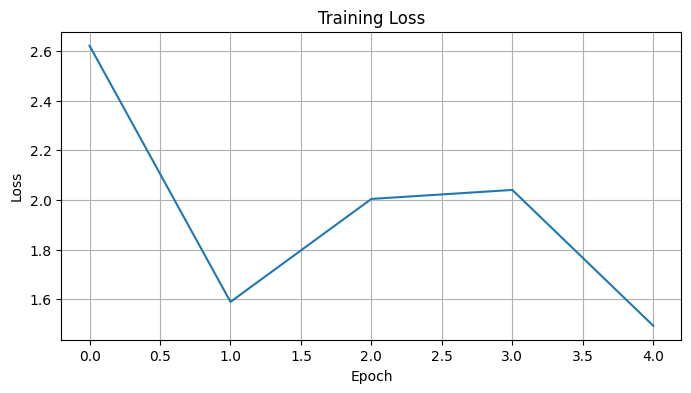

In [107]:
plt.figure(figsize=(8,4))

plt.plot(losses)

plt.title("Training Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.grid(True)

plt.show()

30.Evaluación

In [108]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import f1_score

model.eval()

with torch.no_grad():

    y_pred = model(X_test)

    y_pred = (
        y_pred > 0.5
    ).float()

acc = accuracy_score(
    y_test,
    y_pred
)

f1 = f1_score(
    y_test,
    y_pred
)

print("Accuracy:", acc)

print("F1:", f1)

Accuracy: 0.7142857142857143
F1: 0.0


31. Guardar modelo

In [ ]:
torch.save(
    model.state_dict(),
    f"{BASE}/audio_mlp.pth"
)

print("Modelo guardado")

In [ ]:
test_df = pd.read_csv(
    f"{BASE}/full_test_split.csv"
)

participantes_test = 0

for pid in test_df["Participant_ID"]:

    archivo = f"{BASE}/{pid}_AUDIO.wav"

    if os.path.exists(archivo):
        participantes_test += 1

print("Participantes test con audio:",
      participantes_test)